In [35]:
df = pd.read_csv('q2_customers.csv')

In [36]:
import pandas as pd

df = pd.read_csv('q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)
df_scaled.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-0.725219,-0.176150,0.110166,-0.265011,-0.089951,0.550952
1,-1.488460,-1.046826,0.486157,-0.980466,-0.835176,-0.680685
2,0.176795,0.267337,-0.453822,-0.236851,-0.674046,-0.270139
3,-0.725219,-1.012309,0.298161,-0.827783,-0.996306,-1.091230
4,-1.488460,-1.034488,1.426136,-1.005986,-0.653905,-1.501776


## Step 1: Data Preparation

In this step, I prepared the dataset for clustering by first loading and examining its structure.

Since all features in the dataset are numerical (such as age, annual spend, visits per month, basket size, days since last visit, and number of categories purchased), no encoding was required.

Then, I applied StandardScaler to scale all the features.

Scaling is essential before applying K-Means because it is a distance-based algorithm. Features with larger values can dominate the distance calculations, leading to biased clustering results.

By scaling the data, all features are brought to the same scale, ensuring that each feature contributes equally to the clustering process.

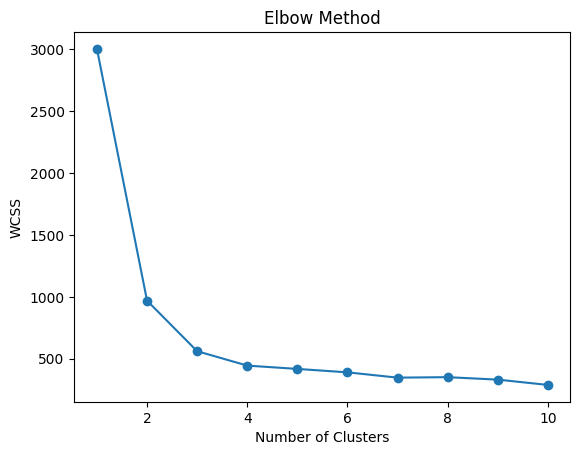

In [38]:
# Step 2: Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

## Step 2: Choosing Optimal Number of Clusters (Elbow Method)

In this step, I used the Elbow Method to determine the optimal number of clusters (K) for K-Means clustering.

The Elbow Method works by plotting the Within-Cluster Sum of Squares (WCSS) against the number of clusters.

As the number of clusters increases, the WCSS decreases. The optimal value of K is chosen at the point where the decrease in WCSS slows down significantly, forming an "elbow" shape in the graph.

From the graph, the optimal number of clusters appears to be 3

In [39]:
# Step 3: K-Means Clustering

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,Cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [40]:
# Centroids

centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.132214,1.235574,-1.106680,1.253260,1.125725,1.172991
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968


## Step 3: K-Means Clustering

In this step, I applied the K-Means clustering algorithm using the optimal number of clusters (K = 3) obtained from the Elbow Method.

Each data point was assigned to a cluster, and a new column 'Cluster' was added to the dataset.

The centroids represent the average values of features for each cluster and help in understanding the characteristics of different customer groups.

Based on the clustering:

- Cluster 0: Customers with lower spending and fewer visits  
- Cluster 1: Customers with moderate spending and average behavior  
- Cluster 2: Customers with high spending and frequent visits  

These clusters help in segmenting customers for better business understanding and decision-making.

In [41]:
# Step 4: PCA

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_components = pca.fit_transform(df_scaled)

pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = df['Cluster']

pca_df.head()

,PC1,PC2,Cluster
0,-0.333082,0.109379,2
1,-2.255362,0.048458,0
2,-0.092905,-0.679257,2
3,-2.017598,-0.308845,0
4,-2.917762,0.529368,0


In [42]:
# Explained variance

pca.explained_variance_ratio_

array([0.83560354, 0.05568764])

In [43]:
# PCA loadings

loadings = pd.DataFrame(pca.components_,
                        columns=df.columns[:-1],
                        index=['PC1', 'PC2'])

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


## Step 4: Dimensionality Reduction using PCA

In this step, I applied Principal Component Analysis (PCA) to reduce the dataset into two principal components (PC1 and PC2).

PCA helps in reducing the dimensionality of the dataset while retaining the maximum amount of variance.

The explained variance ratio indicates how much information is captured by each principal component.

From the results:
- PC1 captures the majority of the variance in the data  
- PC2 captures the remaining significant variation  
- PC1 explains around 83% of the variance, while PC2 explains around 5%, indicating that most information is captured in the first component.

The feature loadings show how strongly each original feature contributes to PC1 and PC2.

This transformation helps in visualizing high-dimensional data in a 2D space.

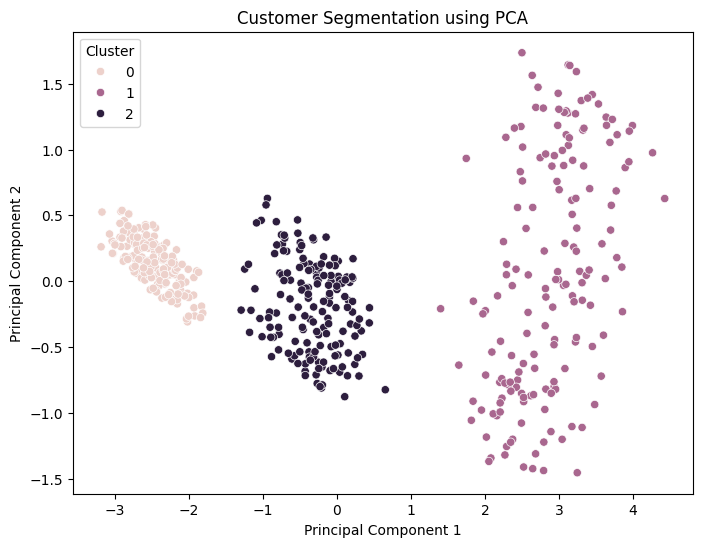

In [44]:
# Step 5: Visualization

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Cluster')

plt.title('Customer Segmentation using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

plt.show()

## Step 5: Cluster Visualization

In this step, I visualized the clusters using a scatter plot of the two principal components (PC1 and PC2).

Each point represents a customer, and different colors represent different clusters.

The visualization shows how customers are grouped based on their behavior.

Distinct clusters indicate that K-Means has successfully segmented the customers into meaningful groups.

The plot includes clear axis labels, title, and legend for better interpretation.